
# DQN from scratch for Continous State Control

Let's formulate the problem in detail. We have a cart-pole system, and our aim is to make sure the pole stays upright. Every time instant the pole stays upright gives us a reward - and every time instant it starts falling off, kills off the reward. 

1. State $S_t$: 4D vector: [cart-position, cart-velocity, pole-angle, pole-angular-velocity]
2. Action $A_t$: Discrete control input: 0 (push left) or 1 (push right)
3. Reward $R_t$: +1 for every time step the pole stays upright
4. Number of episodes: 500
5. Objective: Learn a policy $\pi(a|s)$ which maximum total cumulative future reward (return) $G_t = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}$
6. $\gamma$: discount factor : $\in [0, 1)$
7. Episode Ending Conditions:
    - $|\theta|$ > $12^\circ \rightarrow$ The pole falls over
    - $|x|$ > 2.4 units : the trolley slides off the screen bounds
    - Episode reaches 500 steps (for cartpole-v1)

In [1]:
import torch

In [2]:
# import librarues
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import deque

In [3]:
# 1. Initialize the cartpole environment State Space and Action Space Limits
# add "render" mode as human to make sure to show pop up window shoeing cartpole dynamics
cartpole_env = gym.make("CartPole-v1", render_mode="human")

# 2. Inspect State Space and Action Space Limits
print("Action Space: ", cartpole_env.action_space)
print("Observation Space: ", cartpole_env.observation_space)
obsUpperBounds = cartpole_env.observation_space.high
obsLowerBounds = cartpole_env.observation_space.low

print("Cartpole Position Bounds: [", obsLowerBounds[0], obsUpperBounds[0], "]")
print("Cartpole Velocity Bounds: [", obsLowerBounds[1], obsUpperBounds[1], "]")
print("Cartpole Pole Angle Position Bounds: [", obsLowerBounds[2], obsUpperBounds[2], "]")
print("Cartpole Pole Angular Velocity Bounds: [", obsLowerBounds[3], obsUpperBounds[3], "]")

Action Space:  Discrete(2)
Observation Space:  Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Cartpole Position Bounds: [ -4.8 4.8 ]
Cartpole Velocity Bounds: [ -inf inf ]
Cartpole Pole Angle Position Bounds: [ -0.41887903 0.41887903 ]
Cartpole Pole Angular Velocity Bounds: [ -inf inf ]


In [ ]:
# 3. Reset the environment to start a fresh episode
# reset() returns initial state (observation) and info dictionary
state, info = cartpole_env.reset(seed=42)
print("Initial State: ", state) 

Initial State:  [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]


: 

In [ ]:
# 4. Run a episode with a random policy

## How to run an episode:

"""
Keep looping till terminated or reach Number_of_episodes > N (truncated):

1. sample next action from the policy
2. Implement next action and propagate system
3. Collect next state of system, reward, terminated bool?, truncated bool?, and other misc info
4. Add reward to total reward so far
5. Increment n, and check if n > N

We did some funny business here by doing this 100 times to plot the reward histogram
"""

# 4. Run 1 Episode with a Random Policy
rewards = []
i = 0
while (i < 100):

    terminated = False
    truncated = False
    total_reward = 0
    step_count = 0

    while not (terminated or truncated):
        # Sample a completely random action (0 or 1)
        action = cartpole_env.action_space.sample()
        
        # Apply action to step the dynamics forward by 1 time unit (dt)
        next_state, reward, terminated, truncated, info = cartpole_env.step(action)
        
        total_reward += reward
        step_count += 1
        
     #   print(f"Step {step_count:02d} | Action Taken: {action} | Pole Angle: {next_state[2]:.4f} rad | Reward: {reward}")

    #print(f"\nEpisode finished after {step_count} steps with total reward: {total_reward}")

    rewards.append(total_reward)

    i = i + 1

    # reset:
    cartpole_env.reset(seed=42)

cartpole_env.close()


Text(0.5, 1.0, 'Total rewards for Cartpole with Random Policy')

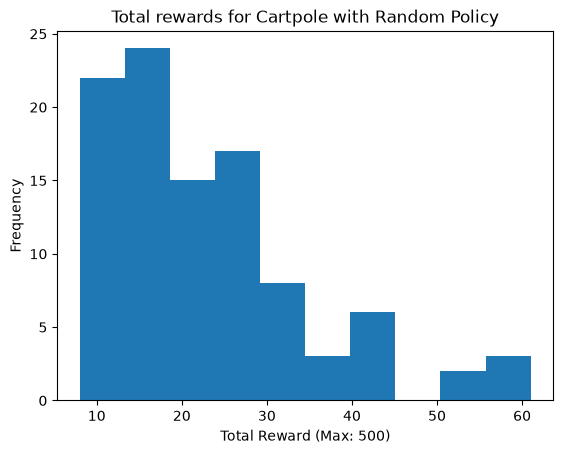

In [ ]:
plt.hist(rewards)
plt.xlabel("Total Reward (Max: 500)")
plt.ylabel("Frequency")
plt.title("Total rewards for Cartpole with Random Policy")

# Bellman Equation

Let's start with the 'return' expression

$$ G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + ... + \gamma^{n-1}R_{t+n}$$
$$ G_t = R_{t+1} + \gamma G_{t+1} $$

What's the action value function? The value of a certain state $s$, taking an action $a$, and then following a policy $\pi$ after that. Let's term is as $Q$.

$$ Q^{\pi}(s, a) = \mathbb{E}_{\pi} \left[G_t | S_t = s, A_t = a \right]$$

Let's substitute the value of the return $G_t$

$$ Q^{\pi}(s, a) =\mathbb{E}_{\pi} \left[R_{t+1} + \gamma G_{t+1} | S_t = s, A_t = a\right]$$

$$ Q^{\pi}(s, a) = \mathbb{E}_{\pi} \left[R_{t+1} | S_t = s, A_t = a \right] + \gamma \mathbb{E}_{\pi} \left[G_{t+1} | S_t = s, A_t = a \right] 
$$

Since, $\gamma$ is a constant, it comes out of the expectation, and $R_{t+1}$ is a constant, since $S_t$, and $A_t$ are fixed. Again, we know, 

$$ Q^{\pi}(S_{t+1}, A_{t+1}) = \mathbb{E}_{\pi} \left[G_{t+1} | S_{t+1}, A_{t+1} \right] $$

Substitute back, and we get the **Bellman's equation.**

$$ Q^{\pi}(s, a) = \mathbb{E}_{\pi} \left[R_{t+1} + \gamma Q^{\pi}(S_{t+1}, A_{t+1}) | S_t = s, A_t = a \right] 
$$


## How to resolve the expectation?

An expectation is the average value: 

$$ \mathbb{E}[X] = \sum_{\forall x_i} p[X = x_i] x_i $$

Similarly, we can solve for $\mathbb{E}_{\pi}$ as follows. Before that, note that a policy is a mapping from the current state to the action to be taken:

$$ s \longrightarrow_{\pi} a $$

Policies can be deterministic $\pi(s) = a$ or stochastic $\pi(s|a) = P(A_t = a| S_t=s)$. Assuming we have a stochastic policy, then the expectation in $\pi$ can be computed as:

$$ \mathbb{E}_{\pi} = \sum_{\forall s, r} p(s', r | s, a) $$

Consider this as: $\pi$ tells us the action to be taken in the current state. Because of stochastic system dynamics, taking an action $a$ doesn't guarantee deterministic next state, and hence the reward as well. Hence, the probability of reaching the state $s'$ and also getting the reward $r$, given the current state was $s$, and action taken was $a$ - is the reason of the expression above.

Now, expand it:

$$ Q^{\pi}(s, a) = \mathbb{E}_{\pi} \left[R_{t+1} + \gamma Q^{\pi}(S_{t+1}, A_{t+1}) | S_t = s, A_t = a \right] = \sum_{\forall s, r} p(s', r | s, a) \left[r + \sum_{a'} \pi(a' | s') Q^{\pi}(s', a')\right] $$

Now, where is the inner summation coming from? The term we have resolved there is basically: $Q^{\pi}(S_{t+1},A_{t+1})$. How do we treat this? In the outer summation, we are computing the probability of reaching state $s'$, and getting reward $r$, but in the inner loop, once we multiple with the probability, we assume that we have reached state $s'$ and got reward $r$, now, what next? Policy $\pi$ recommends the next action $a'$ (stochastically!). 

What is $\pi(a' | s')$? It's the probability of taking action $a'$ while in state $s'$, when we are following policy $\pi$. Because $\pi$ is stochastic, it can spit out multiple options ot actions to take with a probabiity value attached to each. Hence, what is the action-value $Q^{\pi}(s', a')$ it's the expected sum with $\pi(a' | s')$ as probabilities, and corresponding action values as weights.

Hence the action value of the next state is again an expectation in $\pi$: (t's the expectation of $Q^{\pi}(S_{t+1}, A_{t+1})$ over actions drawn from $\pi$ at state $𝑠$)

$$ \mathbb{E}\left[Q^{\pi}(S_{t+1}, A_{t+1})\right] = \sum_{\forall a'} \pi(a' | s') Q^{\pi}(s', a') $$

# Exploration-Exploitation

## Extremely Greedy Policy

Let's design an extremely greedy policy: one which only looks in the very short term, in other words, is extremely myopic. 

$$\pi(a | s) = arg max_a Q(s, a) $$

Choose that action, which has the highest Q-value, for that state-action pair. 

However, when we start any problem at hand, the Q value function is not fully populated, hence many function vallues will still be 0 (what they were initialized with); and because of this myopic view, many Q-value pairs will be left unexploreed, they will never receive an update. This can lead to getting stuck in local minima. 

## $\epsilon$-greedy policy

Now, lets design a different policy which is greedy in general, but with a small probability $\epsilon$ chooses a random action:

$$ \pi(a|s) = arg max_a Q(s, a) \hspace{2mm} \text{with p} = 1 - \epsilon $$
$$ \pi(a|s) = Random(Q(s, a)) \hspace{2mm} \text{with p} = \epsilon $$

$\epsilon$ can be made dynamically changing rather than having a constant value. Usually, $\epsilon$ values are high in the beginning and low towards the end.

# Value Iteration

> The most important aspect of any reinforcement learning problem is to find the globally optimal value function and optimal policy for the MDP which formulates the problem. 

Let's initialize an action value function. Since we don't know any values, we will initialize all of them to zero. Let's consider there are a total of $s_m$ states and $a_n$ actions. So, $Q(s,a)$ is a $s_m \times a_n$ matrix.

Value iteration is a process of finding the True Action-Value function of the MDP at hand. We will be using the Bellman Optimality equation.

$$ Q_{k+1}(s, a) = \sum_{s', r}p(s', r | s, a)\left[ r + \gamma max_{a'}Q_k(s', a')\right] $$

Also, called the Bellman optimality operator. And by Banach fixed-point theorem: $Q_k \longrightarrow Q* \hspace{2mm} \text{when} \hspace{2mm} k \longrightarrow \infty $

$Q*$ is the globally optimal value function.

Here: the $r + \gamma max_{a'}Q_k(s', a')$ is the Bellman target. It is the true value we want our network to predict. Why? Because we always want to go into states with high actio-values. Look at the $max_{a'}$, it's essentially saying: scan all the value functions at $s'$ for all possible actions $a'$ and find the maximum.

# Policy Iteration

Policy iteration also finds the optimal policy but through a different route. It initializes a random policy, then evaluates it, and iterates on it. Eventually the random policy converges towards the globally optimal policy. 

1. Policy Evaluation: Solve linear system for $Q^{\pi}$:
$$ Q^{\pi}(s, a) = \sum_{s', r}p(s', r | s, a)\left[r + \gamma \sum_{a'}\pi(a' | s') Q^{\pi}(s', a')\right] $$

2. Policy Iteration:
$$ \pi_{new}(s) = arg max_a Q^{\pi_{old}}(s, a) \hspace{2mm} \forall s$$

> In a nutshell: 
1. Initialize $\pi$ random, initialize $Q(s, a)$ with zeros everywhere
2. Evaluate: Iterate expectation $\rightarrow Q^{\pi}$
3. Improve: $\pi'(s) = arg max_{a} Q^{\pi}(s, a) $
4. Evaluate $\pi'$: iterate expecctation $\rightarrow Q^{\pi'}$ (can start from 0)
5. Repeat until $\pi' = \pi*$

## Bellman Expectation vs Bellman Optimality:
1. Bellman Expecation Equation (for $Q^{\pi}$): Uses the expected summation, because we are using policy $\pi$ and we don't know how that policy operates. Hence we do an expectation under the current policy $\pi$ : $$\sum_{a'}\pi(a' | s')Q(s' , a')$$ Bellman expectation evaluates a specific policy $\pi$. If we do the iterations, then we will converge to $Q^{\pi}$ (the value of that policy). THIS IS NOT NECESSARILY the OPTIMAL value function.

$$ Q^{\pi} \leq Q* $$
$$ Q^{\pi} = Q* \hspace{2mm} \text{when} \hspace{2mm} \pi = \pi* $$

2. Bellman Optimality Equation (for $Q*$): Uses $max_{a'}Q(s', a')$ it assumes we pick the best action at s'. Iterating this will directly lead us to the GLOBALLY OPTIMAL VALUE FUNCTION $Q*$, and the OPTIMAL POLICY $\pi*$, which is as follows:

$$ \pi* = max_{a} Q(s, a) $$

# DQN Implementation

Remember the cartpole environment gives us 4 states:
1. Cart position
2. Cart velocity
3. Pole angular position
4. Pole Angular velocity

The only actions available to us are:
1. Push cart in left direction
2. Push cart in right direction

In [4]:
import torch.nn as nn

## DQN Architecture

DQN are usually architected as follows:
1. Input: State Only (4D)
2. Output: $Q$-value(s) for each action (since we have 2 actions - there are going to be 2 Q-values for each state. Q(s, 0), and Q(s, 1) OR Q(s, left), and Q(s, right))

The Input (State, Action) -> Output (Scalar: Q(s, a)) design is usually used for Q-learning with a table or for actor-critic. 

### Why we not using Tabular Q-Learning?
Cart-Pole state is continouos (4-floats). A tabular Q-table would need discretization - grid size explodes and accuracy suffers are boundaries. DQN approximates Q(s, a) continously with a network, removing the need for a grid.

In [5]:
class CartPoleDQN(nn.Module):

    def __init__(self, state_dim=4, action_dim=2):

        super(CartPoleDQN, self).__init__()

        self.layer1 = nn.Linear(state_dim, 24)
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(24, action_dim)

    # pass the input through the network
    def forward(self, x):

        out = self.layer2(self.relu1(self.layer1(x)))
        return out

# Environment Interaction Loop

Let's write the loop where in the agent interacts with the environment. 

1. We run this for $n$ episodes.
2. Need to store the sequence $s, a, r, s'$

There's a very interesting gimmick we have done here: and also very counter intuitive. 

1. We initialize the problem at a random initial state $s0$.
2. The network knows nothing currently : it has random weights, and its generating random outputs.
3. Using this network as the $Q$-value function, we compute the Q-values at state $s0$ {$Q(s, a_1), Q(s, a_2), ..., Q(s, a_n)$}: and take an $\epsilon$-greedy action based on that.
4. Based on the action, the state now progresses and our system reaches in the next state, and we get a reward for this.
5. Now, what was the prediction $Q(s, a_1), Q(s, a_2)$?: It was the network's guess for "how good is action $a_i$ at state $s$"?
6. Target: According to the Bellman equation: what is the correct (most desirable) value of $Q(s, a)$? It is: $r + \gamma \text{max}_{a'} Q(s', a')$, where $s'$ is the state reached after state $s$ upon taking action $a$. 

Note this expression one more Q-value again - how do we find that? Again use the network. 

I know it's counter-intuitive, we are computing the target to compute the loss $($ target - prediction $)^2$. But to compute target as well as prediction we are again using the same network - which we know is something we want to train. So in essence we are using the same network to generate training data and then train itself. 

Counter-Intuitive but works! Need to go into Banach Convergence and crazier shit, but not needed. 

### Why we need Target Network?
This is exactly why DQN needs a target network (frozen copy) — to stabilize this self-referential loop. Without it, the target moves every update, making training unstable. Your intuition is spot on.

# Training Loop

In [6]:
def epsilonGreed(actions, epsilon=0.9):

    # simulate uniformly generated random number between 0 and 1
    num = np.random.random(1)

    if num > epsilon:

        # choose greedy action
        return torch.argmax(actions).item()

    else:
        # return random index between 0 or 1
        return np.random.randint(0, 2)

In [ ]:
bigStore = []
n_episodes = 500
gamma = 0.9

# initialize the network
CartPoleRL = CartPoleDQN()

# define optimizer and loss criterion
CartPoleLoss = torch.nn.MSELoss()
CartPoleOptimizer = torch.optim.SGD(CartPoleRL.parameters(), 
                            lr=0.05,
                            weight_decay=0.01)

for i in range(n_episodes):

    # initialize with random state
    s0, info = cartpole_env.reset()

    # lets store some important variables
    ## store: state, action taken, reward, next_state, and termination status
    perEpisodeStore = []

    # convert s0 to tensor
    s0 = torch.as_tensor(s0, dtype=torch.float32)

    terminated, truncated = False, False

    while not (terminated or truncated):

        # zero the gradients, to ensure no accumulated gradients
        CartPoleOptimizer.zero_grad()

        # compute the Q-values using the network
        Qvals = CartPoleRL.forward(s0)

        # use epsilon-greedy stuff
        actIndex = epsilonGreed(Qvals)

        # propagate the state using the obtained action
        next_state, reward, terminated, truncated, info = cartpole_env.step(actIndex)

        # convert next state to tensor
        next_state = torch.as_tensor(next_state, dtype=torch.float32)

        # now compute the best Qvalue that can be obtained at state = next_state
        if terminated or truncated: # no more gamma needed: last state
            target = reward 
            # convert target (float) to tensor
            target = torch.tensor(target)
        else:
            # target shouldn't have gradients  
            with torch.no_grad():
                QnextState = CartPoleRL(next_state)
                target  = reward + gamma * QnextState.max()

        # compute loss: between what our network predicts and what we need
        predicted = Qvals[actIndex]
        loss = CartPoleLoss(target, predicted)

        # Do backward pass and optimize gradients
        loss.backward()
        CartPoleOptimizer.step()

        # store 
        ## done: terminated is where the CartPole fell off, so MDP failed
        ## done: truncated is where the number of iterations or max time steps ended
        ## for this example, it doesn't matter how the episode ended: can be configured via max_epipsode_steps in gym                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     
        done = terminated or truncated
        perEpisodeStore.append([s0, actIndex, reward, next_state, done])

        # update current state to next state
        s0  = next_state

    # store in global episodes
    bigStore.append(perEpisodeStore)

# Experience Replay Buffer

## Why do we need any such Experience Replay? Isn't learning on the fly not good enough?

Let's see. We use Stochastic Gradient Descent in our optimization loops - it has a fundamental assumption: samples are independent and identically distributed. 

In normal supervised learning, we can reshuffle the dataset and sample random batches - which is a subset of the whole distribution of the dataset - making it i.i.d.

In RL, because we don't have a dataset (yet!) we are learning with every transition (s, a, s', r) the system makes. And because the physical world is continous, these adjacent states are continous, and hence co-related. The rewards are too!

Because of that; the updates to the Q-network aren't significant, and are slow. Hence, the policy (which is just $\epsilon$-greedy on the Q-network) doesn't update fast as well. So the agent keeps executing similar actions, and keeps seeing similar states and rewards. 

The risks are:
1. gradient biased by recent trajectory
2. optimizer chases recent experience and overfits to it
3. oscillations, divergence and forgetting

## What it does?
1. It stores experience tuples in memory (s, a, s', r) and samples a batch from that for training. 
2. You can up-sample: if certain scenarios gain higher reward, you can use the same transition for multiple gradient updates

## Bellman Residual

Write down the Bellman Optimality Equation

$$ Q^{\pi}(s, a) = \mathbb{E} \left[ r + \gamma \text{max}_{a'} Q^{\pi}(s', a') | s, a \right] $$

$$ \text{Bellman Residual = } Q(s, a) - \mathbb{E} \left[ r + \gamma \text{max}_{a'} Q(s', a') | s, a \right]$$

For the **true** Q function ($Q*$), the Bellman residual becomes zero. However, we are using a neural network $Q(s, a, \theta)$ ($\theta$ represents the weights, biases, parameters as a whole). Let's substitute that in the equation:

$$ \text{Bellman Residual = } \delta(s, a; \theta) = Q_{NN}(s, a, \theta) - \mathbb{E} \left[ r + \gamma \text{max}_{a'} Q_{NN}(s', a', \theta) | s, a \right]$$

We know from earlier, on how to expand this expectation:

$$ \text{Bellman Residual = }  Q_{NN}(s, a, \theta) - \sum_{\forall s, r} p(s', r | s, a) \left[ r + \sum_{a'} \pi(a' | s') Q^{\pi}(s', a') \right ] $$

We don't know the dynamics model, hence we don't know how to resolve $p(s', r | s, a)$. What we hvae from the environment is only the experience tuples. For one particular sample only, the probability terms disappear. 

$$ \delta_{\text{sample}}(s', r, s, a; \theta) = Q_{NN}(s, a, \theta) - \left[ r + \gamma max_{a'}Q(s', a', \theta) \right] $$

Remember, the experience tuple, doesn't tell use the next action $a'$ hence we still need to take maximum over all actions. Now, for every experience tuple we need to make the Bellman residual zero, hence this becomes the loss function parameterized in $\theta$. 

DQN uses the Mean Squared Bellman Error

$$L(\theta) = \mathbb{E}_{(s, a, r, s') \sim D} \left[ \left(Q(s, a, \theta) - \left(r + \gamma max_{a'}Q(s', a', \theta) \right) \right)^2\right] $$

Now, $L(\theta)$ is for a single experience tuple, we average this over all the experience tuples found in the replay buffer distribution and minimize that. 

A caveat: When $s'$ is the final state (proces terminates or truncates) then there is no more discounting, hence the Bellman Residual becomes:

$$L(\theta) = \mathbb{E}_{(s, a, r, s') \sim D} \left[ Q(s, a, \theta) - r \right] $$


# What happens to the Bellman Residual Without the Experience Buffer?

Let's first look at what is $D$. $D$ is the true stationary distribution of transitions under the optimal policy. At every step $t$ the experience distribution is $D_t$ and it is non-stationary - because it's the distrbution of he current trajectory under the current policy. However with each gradient update the Q-network updates and hence $\pi_t$ which is $argmax_{a}Q_t(s, a)$ also changes. Hence, the subsequent experience tuples $D_{t+1}$ are not distributed in the same way as $D_t$. 

What the replay buffer does its: It stores many experience tuples from many different phases of the policy evolution - and hence is a mixture of various past experience distributions $D_1, D_2, D_3, ..., D_t$. Due to this mixing the buffer fills and it approaches a more stationary distribution. Random sampling from it gives you something closer to i.i.d samples from a fixed distribution - which then helps the SGD updates we make.

# Buffer design best practices

1. Too small: not diverse enough, forgets old experiences fast
2. Too large: Memory heavy, includes old transitions from bad policy (slower convergence)
3. 10k-100k for CartPole, 1M for Atari. Depends on the environment complexity

# Difference Between Online Training and Buffer based Training

## Online Training

```
for each episode:
    for each step:
        act → observe (s, a, r, s', done)
        compute target using CURRENT network
        loss = MSE(target, Q(s,a))
        backward() → optimizer.step()   ← TRAIN HERE, EVERY STEP
```

We update the model weights every environment step - on the exact transition we just experienced. Here buffer is not needed - however the subsequent transitions are extremely co-related. 

## Replay Buffer Training

```
for each episode:
    for each step:
        act → observe (s, a, r, s', done)
        buffer.push(transition)          ← STORE ONLY
        
        if len(buffer) >= min_size:      ← CONDITION TO TRAIN
            batch = buffer.sample(64)    ← RANDOM BATCH FROM PAST
            compute targets using TARGET network
            loss = MSE(targets, Q(batch))
            backward() → optimizer.step() ← TRAIN ON BATCH
```

Here we do not train (update weights) on every environment transition. We train on random historical transitions, not the current one. Completely avoid training till we have got enough samples in the buffer. 

> IMPORTANT NOTE: THE BUFFER IS FIFO. AS NEWER TRANSITIONS ARE PUSHED, OLDER TRANSITIONS ARE REMOVED, HENCE FORGOTTEN.

# How the Buffer evolves?

The buffer at time $t$ contains a mixture of transitions from all past policies. 

$$ \text{Buffer}(t) = \{ \text{transitions from} \hspace{2mm} \pi_1, \pi_2, \pi_3, ..., \pi_t \} $$

where $π_1$ is the terrible random policy, $π_2$ slightly better, ..., $π_t$ the current policy.  The buffer does NOT "forget" the bad transitions. It keeps them until they're evicted (FIFO). So even late in training, the buffer still contains a large fraction of old, bad-policy transitions.

The buffer's job is diversity, not quality: The buffer exists to give SGD i.i.d., diverse samples — not "good" samples. A mix of good and bad transitions is actually desirable for stability:

- Bad transitions → explore the state space broadly
- Good transitions → refine near-optimal behavior

The buffer's state distribution lags behind the current policy.

- Early: buffer full of states the random policy visits
- Later: the good policy visits different states (e.g., pole stays near upright longer)
If the buffer is too small, it gets flooded with recent (good) transitions and forgets the early states → the network overfits to the current policy's states → instability.

If the buffer is too large, it's dominated by old (bad) transitions → the network keeps learning from states the current policy never visits → slower convergence

Reasons that DQN works is not that buffer becomes good. It's that:
1. Off-policy Bellman update extracts Q* from any data
2. Replay stabilizes SGD by decorrelating samples
3. Target network stabilizes the moving target

# Off-Policy Learning

Let's look at how the DQN algorithm works:
1. Behavior policy $\pi_t$: $\epsilon$-greedy on $Q_t$
2. Generates environment transitions or experience tuples (s, a, r, s')
3. Replay buffer stores the tuples
4. Sample-Batch from Buffer + Compute prediction
5. Compute target using argmax: max-greedy policy: independent of current policy $\pi_t$
6. Compute loss function 
7. Update Q-learning weights

The Behavior policy is only used for generating data. The learning update ignores $\pi_t(a|s) = \epsilon-\text{greedy}(Q)$ entirely and targets the optimal policy $\pi^*(a|s) = argmax_{a} Q(s, a)$.

> A method is off-policy if it learns the value of the target policy $\pi^*$ using data generated by a different policy $\pi_t$.

# Distribution Mismatch Issue

In Off-policy RL, there are 2 important distributions over actions/states:

1. Behavior Distribution: $D_{\mu}$: States/actions done by the current policy $\pi_t$ ($\epsilon$-greedy)
2. Buffer Distribution: $D_{\text{buffer}}$ mixture of states/actions done by all the past policies

The mismatch happens when $D_{\mu} \neq D_{\text{buffer}}$.

In early phases of training the policy $\mu$ is naive and mostly random, and contains many failure states. The cart's all over the place, the pole tilts too much and their are frequent falls. In later phases, the policy has matured, and now most of its actions are greedy - keeping the cart centered, not allowing it to tilt and fall. 

Since the buffer is a history of all the policies so far, it contains a mixed distributions of failed transitions and a random policy fro earlier training epochs, and then successful episodes and matured policy interactions from later one.

Lets say: It has 10k capacity. It has 2k earlier transitions, and 8k in the later stage.

## How is that a problem? Lets see
### Wasted Capacity (Stale Data): 
Consider a late training phase
1. Current policy visits: pole angle ∈ [-0.1, 0.1] rad
2. Buffer has: pole angle ∈ [-0.5, 0.5] rad (from early random falls)
3. 50% of buffer = states the agent will NEVER see again

> But because we do random sampling from the buffer, we are going to pick some of these states inadvertently even if we don't want them. That's going to lead to an update in the Q-values of those states.. But that's pointless, since we are updating Q-values of failure states, and our policy has matured enough that it's not going to ever visit those states - or so to say the probability it too low.

### Missing Coverage
Again consider a late training phase:
1. Early training phases contains transitions from a policy which has never learnt to balance. 
2. Late training has transitions from a policy which has better balance states
4. However if the buffer is too long, it has a lot of "bad" transitions from early training but next to nothing from the latest "good" policy interactions. 

> In the late training phase the policy actually operates in the "good" regime, but the buffer now has nothing in that regime to refine the Q-values of the states the policy is actually visiting. Q-values of those states are untrained, garbage. 

### Basied Gradient Estimates
$$L(\theta) = \mathbb{E}_{(s, a, r, s') \sim D_{\text{buffer}}} \left[ \left(Q(s, a) - target\right)^2\right]$$

This is the loss function on the buffer distribution, it's essentially, how good the predictions of the current policy are on states/actions in the buffer. SGD tries to minimize this and then update the weights of the network approximating $Q(s, a)$. Here, it is almost as if, we are optimizing the current policy on past behaviors. However we care about how our policy's prediction is on the current state/action distribution:

$$ J(\theta) = \mathbb{E}_{s \sim D_\mu} \left[ Q(s, \pi(s)) \right] $$

However the states/actions done by the current policy will enter the buffer next, but by then the curent policy has drifted. This imbalance is the core of the distribution mismatch.

If $D_{\text{buffer}} \neq D_{\mu}$ then minimizing $L(\theta)$ doesn't necessarily improve $J(\theta)$.

## Practical Considerations
1. Training loss great, eval performance very bad: over optimizedd for the buffer distribution, and not for the current policy distribution
2. Agent forgets to recover from near-fall states: Buffer is FIFO, if its short, then those states are going to be expelled, since near-fall states usually occur near early phases in training
 
> #2 is a very important caveat. It mentions that the agent forgets to recover from near fall states. Again, since the policy has matured enough it's mostly not ever going to reach that state, however, a policy is simply a probabilistic map from the domain of states to the domain of actions. And even if the probability is near zero, there's a non-zero chance that the trained policy might take thhe system to a near-fail state - and now that's a problem! Since our policy has forgotten how to recover from near fall states. Hence, in safety-critical and real-time systems with hard operational constraints, RL systems are not provably safe. A hand wavy argument but enough to drive home the point. 

3. Learning slows down: Buffer is too long; it has too mnay "bad" transitions, which it keeps showing.
4. Instability when buffer is too large: stale data overpowers current data

# The Moving Target Problem

The weight update for every transition is as follows:

$$ \text{target} = r + \gamma \text{max}_a' Q(s', a'; \theta) $$
$$ loss = \left( target - Q(s, a; \theta) \right)^2 $$

We are chasing a target which depends on $\theta$, by computing a loss function with the target and $Q(\theta)$, and with the loss we will update the parameters $\theta$. So target is moving with the parameters we are updating to optimize our current Q wrt to the target.

> A dog trying to bite his own tail. Self-referential problem. As opposed to Supervised Learning, where labels are fixed and do not change. 

> $$ \theta \hspace{2mm} \text{changes} \rightarrow Q(s', a'; \theta) \hspace{2mm} \text{changes} \rightarrow \hspace{2mm} \text{target changes} \rightarrow \hspace{2mm} \text{gradient changes} \hspace{2mm} \rightarrow \theta \hspace{2mm} \text{changes} \hspace{2mm} \rightarrow \dots $$

## Why is this dog-tail problem happening?

Consider $\mathcal{T}$ to be the Bellman operator. So, 
$$ \mathcal{T}\{Q(s, a)\} = \mathbb{E}\left[r + \gamma \text{max}_{a'} Q(s', a') \right]$$

We are trying to solve the fixeed point equation $\mathcal{T}(Q) = Q$ Without the target network, we are doing the followig weight update in the SGD phase:

$$ \theta \leftarrow \theta - \alpha \nabla  \left(Q_{\theta} - \mathcal{T}(Q_{\theta})\right)^2 $$

where, $\left(Q_{\theta} - \mathcal{T}(Q_{\theta})\right)$ is the squared loss function. However, note that bith $Q_{\theta}$ as well as $\mathcal{T}(Q_{\theta})$ depend on $\theta$. So we are not minimizing the distance to a fixed point - we are minimizing the distance to a moving target - because we are updating $\theta$ in every step.

## With a Target Network

We freeze the $\theta_{target}$ for $N$ steps. Now, we are not minimizing distance to a moving target - we are chasing a fixed/stationary target. Hence the update law becomes:

$$ \theta \leftarrow \theta - \alpha \nabla \left( Q_{\theta} - \mathcal{T}(Q_{\theta_{\text{target}}}) \right)^2 $$

## Delusional Network
Without a stationary target network, the learned Q-network can become delusional. 

1. Network overestimates $Q$ for some action.
2. The inflated $Q$ becomes the target for predecessor states. Here, by predecessor states I mean, to say: Let's say the $Q(s)$ is inflated, now for all the state-action pair who are going to follow the transition $(s', a, r, s)$ this new inflated $Q$ function becomes the target.
3. Because of this inflation of targets for predecessors - their Q increases - and this prpopagates backward - entire Q-function inflates.
4. Policy keeps doing the max greedy on this inflated Q - hence it visits states which are good, but aren't.
5. Classic value-over-estimation and delusional bias.

Another way to look at how freezing the target network helps is as follows:

$$ \text{loss} \hspace{2mm} = \left( r + \gamma \text{max} Q_{\theta}(s') - Q_{\theta}(s, a) \right) ^2 $$

$$ \nabla \text{loss} \hspace{2mm} = 2 \left(Q_{\theta}(s, a) - target\right) \times \left( \nabla Q_{\theta}(s, a) - \gamma \nabla \text{max} Q_{\theta}(s') \right) $$

Look at the last term $\nabla \text{max} Q_{\theta}(s')$, its the gradient of the max of the current value function (which depends on $\theta$). It's coupling the target gradient with the prediction gradient. 

The target network decouples them:

$$ \nabla loss = 2 \left( Q_{\theta}(s, a) - \text{target\_fixed} \right) \times \nabla Q_{\theta}(s, a) $$

## Update Strategy

For $C$ Steps: $\theta'$ is FIXED:
1. target = $r + \gamma \text{max} Q_{\theta'} (s')$ is FIXED
2. loss = $\left(\text{fixed\_target} - Q_{\theta}(s, a)\right)^2 $

After $C$ steps:
1. Update $\theta'$ with the current $\theta$
2. Can either do hard update eor can do soft update:
3. Hard Update: $\theta' = \theta$ (do once every $C$ steps - original DQN)
4. Soft Update: $\theta' = \tau \theta + (1 - \tau)\theta' \hspace{2mm} \tau \approx 0.001 $ (can do every step as well - DDPG/SAC style)

# Epsilon Decay

1. $\epsilon$ is the parameter which controls the exploration-exploitation ratio. Keep it high close to 1: it will do more exploration. Let's say if $epsilon$ is 0.9: then it means it will tak 90% random actions, and 10% exploitative actions. Hence in later stages of learning, even after the policy has formalized - the agent still wastes time visiting unimportant states and taking random actions and never exploits the learned behavior. 

## Why decay needed?
1. Early state: explore broadly, discover the stat-space: high $\epsilon$
2.  Middle: Balance, explore uncertain areas, exploit known high value areas: lower $\epsilon$
3. Late: exploit the learned policy, fine-tune: Lower $\epsilon$
4. Eval: Pure-greedy, measure true performance: make it $0$

# DQN with Bells and Whistles

## Replay Buffer Implementation

In [7]:
# Lets start implementing the Replay Buffer
class ReplayBuffer:

    def __init__(self, buffCap = 10000):
        self.buffer = deque(maxlen=buffCap)

    # push an experience tuple in the buffer
    def push(self, 
             state: torch.tensor,
             action: int, 
             reward: float, 
             next_state: torch.tensor, 
             done: bool):
        
        self.buffer.append((state, action, reward, next_state, done))

    # sample a mini batch of 'batch_size' number of experience tuples
    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        # convert into torch compatible objects
        states = torch.stack(states)

        """
        Why are we using long data type for actions:

        # In training loop:
        q_pred = q_online(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        1. q_online(states) → shape [batch_size, 2] (Q-values for both actions)
        2. actions → shape [batch_size] containing 0 or 1
        3. .gather(1, actions.unsqueeze(1)) → indexes into dimension 1 to pick the Q-value for the action taken
        4. PyTorch requires index tensors to be torch.long (int64)
        5. If you used float32 for actions, .gather() would throw an error.
        """
        actions = torch.tensor(actions, dtype=torch.long)
        rewards = torch.tensor(rewards, dtype=torch.float32)
        next_states = torch.stack(next_states)
        dones = torch.tensor(dones, dtype=torch.float32)

        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

    # check if buffer is ready to start training
    def is_ready(self, min_size: int):
        return len(self.buffer) >= min_size


## Test Replay Buffer Implementation

In [8]:
# let's add some testing code to see if we have implemented the Replay Buffer correctly
ReBuff = ReplayBuffer(3)

# try pushing experience tuple
ReBuff.push(torch.tensor([0.4, 0.1, 0.2, 0.3]), 1, 0.5, torch.tensor([0.6, 0.1, 0.2, 0.3]), False)
ReBuff.push(torch.tensor([0.5, 0.2, 0.3, 0.4]), 0, 0.3, torch.tensor([0.2, 0.3, 0.4, 0.5]), False)
ReBuff.push(torch.tensor([0.3, 0.3, 0.4, 0.5]), 1, 0.2, torch.tensor([0.4, 0.4, 0.5, 0.6]), False)

# print and check if first 2 values were pushed
print("After 3 pushes: \n", ReBuff.buffer)

# push fourth value
ReBuff.push(torch.tensor([0.7, 0.4, 0.5, 0.6]), 1, 0.4, torch.tensor([0.1, 0.5, 0.6, 0.7]), False)

# print one more time: check if first value was flushed out to accomodate third value
print("After 4th push: \n", ReBuff.buffer)

# draw a sample of batch size = 2
states, actions, rewards, next_states, dones = ReBuff.sample(2)
print(f"States shape: {states.shape}")      # Should be [2, 4]
print(f"Actions shape: {actions.shape}")    # Should be [2]
print(f"Rewards shape: {rewards.shape}")    # Should be [2]
print(f"Next states shape: {next_states.shape}")  # Should be [2, 4]
print(f"Dones shape: {dones.shape}")        # Should be [2]
print(f"Actions dtype: {actions.dtype}")    # Should be torch.int64 (long)

After 3 pushes: 
 deque([(tensor([0.4000, 0.1000, 0.2000, 0.3000]), 1, 0.5, tensor([0.6000, 0.1000, 0.2000, 0.3000]), False), (tensor([0.5000, 0.2000, 0.3000, 0.4000]), 0, 0.3, tensor([0.2000, 0.3000, 0.4000, 0.5000]), False), (tensor([0.3000, 0.3000, 0.4000, 0.5000]), 1, 0.2, tensor([0.4000, 0.4000, 0.5000, 0.6000]), False)], maxlen=3)
After 4th push: 
 deque([(tensor([0.5000, 0.2000, 0.3000, 0.4000]), 0, 0.3, tensor([0.2000, 0.3000, 0.4000, 0.5000]), False), (tensor([0.3000, 0.3000, 0.4000, 0.5000]), 1, 0.2, tensor([0.4000, 0.4000, 0.5000, 0.6000]), False), (tensor([0.7000, 0.4000, 0.5000, 0.6000]), 1, 0.4, tensor([0.1000, 0.5000, 0.6000, 0.7000]), False)], maxlen=3)
States shape: torch.Size([2, 4])
Actions shape: torch.Size([2])
Rewards shape: torch.Size([2])
Next states shape: torch.Size([2, 4])
Dones shape: torch.Size([2])
Actions dtype: torch.int64


# Implement Target Network and Update Helpers

In [9]:
def create_target_network(current_network: nn.Module) -> CartPoleDQN:

    """
    Creates a frozen copy of the current network
    """

    target_network = CartPoleDQN()

    # copy contents of the current_network into target_network
    target_network.load_state_dict(current_network.state_dict())

    # set target_network into eval mode: basically same as torch.no_grad()
    target_network.eval()

    # freeze all the parameters in the target network
    for param in target_network.parameters():
        param.requires_grad = False

    # return
    return target_network

def update_target_network(target_network: nn.Module, current_network: nn.Module, tau=1.0)->None:

    """
    Implements the hard and soft update rules for the target network
    1. tau=1.0 -> hard update (original DQN)
    2. tau=0.001 -> soft update (DDPG/SAC style)
    """

    for target_param, online_param in zip(target_network.parameters(), current_network.parameters()):
        target_param.data.copy_(tau * online_param.data + (1 - tau) * target_param.data)

## Test the Target Network Class and Helpers

In [10]:
# Test target network creation
online_test = CartPoleDQN()
target_test = create_target_network(online_test)

print("Online params require_grad:", any(p.requires_grad for p in online_test.parameters()))
print("Target params require_grad:", any(p.requires_grad for p in target_test.parameters()))
print("Weights equal initially:", 
      all(torch.equal(p1, p2) for p1, p2 in zip(online_test.parameters(), target_test.parameters())))

# Test update
with torch.no_grad():
    for p in online_test.parameters():
        p.add_(1.0)  # change online weights

update_target_network(target_test, online_test, tau=1.0)
print("Weights equal after hard update:", 
      all(torch.equal(p1, p2) for p1, p2 in zip(online_test.parameters(), target_test.parameters())))

Online params require_grad: True
Target params require_grad: False
Weights equal initially: True
Weights equal after hard update: True


# Epsilon Decay

In [11]:
def epsilon_greedy(action_values, epsilon: float):

    """
    acion_values: torch.Tensor or shape [2]
    epsilon: probability of random (non-greedy) action
    """

    if np.random.random() < epsilon:
        return np.random.randint(0, len(action_values))
    else:
        return torch.argmax(action_values).item()

def decay_epsilon(epsilon: float, min_epsilon: float = 0.01, decay_rate: float = 0.995):

    """
    We use exponential decay; there are many available mthods, like linear decay etc.
    """
    return max(min_epsilon, epsilon * decay_rate)

# Evaluation Helpers 